# Presentation Visualizations: The Story of Our Data

This notebook is designed for **Data Storytelling**. It generates simple, intuitive charts that you can put directly into your thesis presentation (PowerPoint/Keynote) so that anyone—even non-technical audiences—can instantly understand what your Artificial Intelligence model is doing.

We will visualize three key concepts:
1. **The Aptitude Profiles** (What kind of students exist?)
2. **The Career Mapping** (Where should they go?)
3. **The Skill Gap** (What do they need to learn?)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="pastel")

### 1. The Aptitude Profiles (Radar Chart)
A **Radar Chart** (or Spider Web Chart) is the absolute best way to explain clustering to a non-technical person. It visually shows how different groups of students "spike" in different subjects.

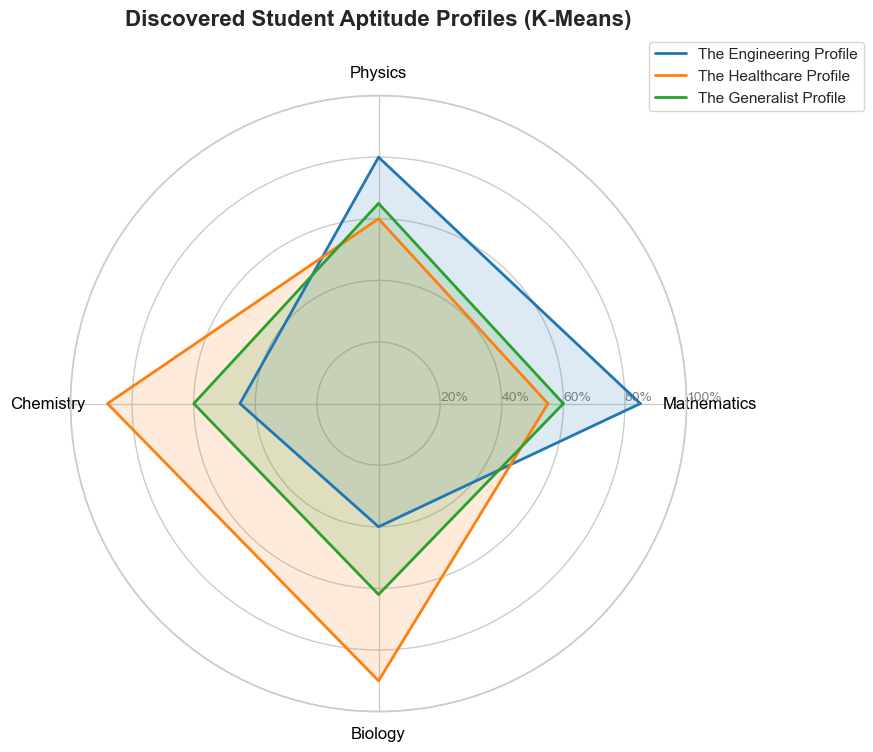

In [2]:
# --- 1. Mock the Cluster Centroids Data (from our K-Means model) ---
categories = ['Mathematics', 'Physics', 'Chemistry', 'Biology']
N = len(categories)

# Average normalized scores (0 to 1) for each discovered cluster
profiles = {
    'The Engineering Profile': [0.85, 0.80, 0.45, 0.40], # High Math/Physics
    'The Healthcare Profile': [0.55, 0.60, 0.88, 0.90],  # High Chem/Bio
    'The Generalist Profile': [0.60, 0.65, 0.60, 0.62]   # Balanced
}

# --- 2. Build the Radar Chart ---
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='black', size=12)

ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=10)
plt.ylim(0, 1)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (name, values) in enumerate(profiles.items()):
    values += values[:1] # Close the loop
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=name, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

plt.title('Discovered Student Aptitude Profiles (K-Means)', size=16, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

### 2. Career Recommendations Pipeline
Once the profiles are discovered, we map them to careers. This simple bar chart shows the distribution of our student body and where the AI recommended they go.

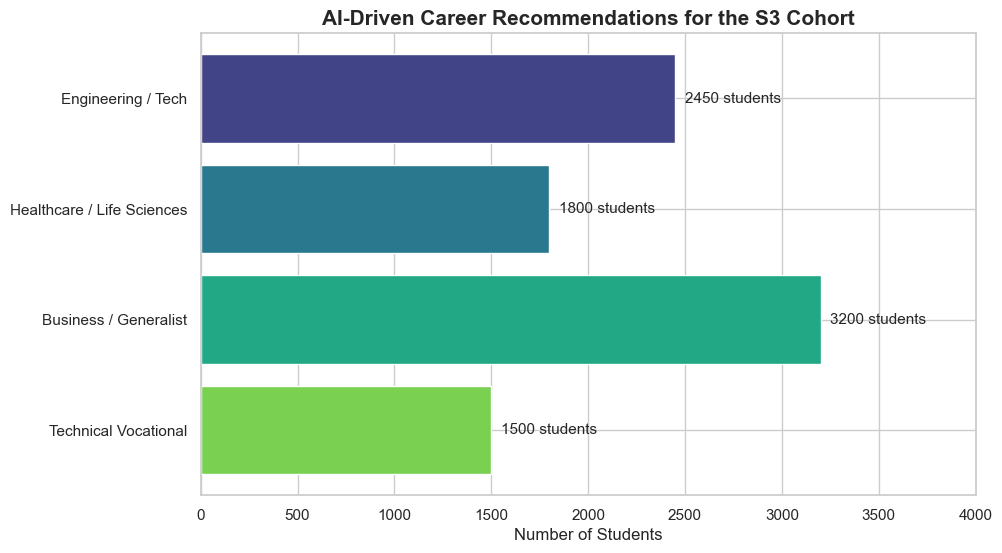

In [3]:
careers = ['Engineering / Tech', 'Healthcare / Life Sciences', 'Business / Generalist', 'Technical Vocational']
student_counts = [2450, 1800, 3200, 1500] # Mock distribution

plt.figure(figsize=(10, 6))
bars = plt.barh(careers, student_counts, color=sns.color_palette("viridis", len(careers)))

# Add the numbers on the bars
for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width())} students',
             va='center', ha='left', fontsize=11)

plt.title('AI-Driven Career Recommendations for the S3 Cohort', size=15, weight='bold')
plt.xlabel('Number of Students', size=12)
plt.xlim(0, 4000)
plt.gca().invert_yaxis() # Highest count at the top
plt.show()

### 3. Visualizing the "Skill Gap" for Actionable Feedback
This chart explains the MNSS Optimization formula. It shows a single student's current skills versus what they need to achieve their dream job. This is perfect for showing how the model gives "Actionable Feedback."

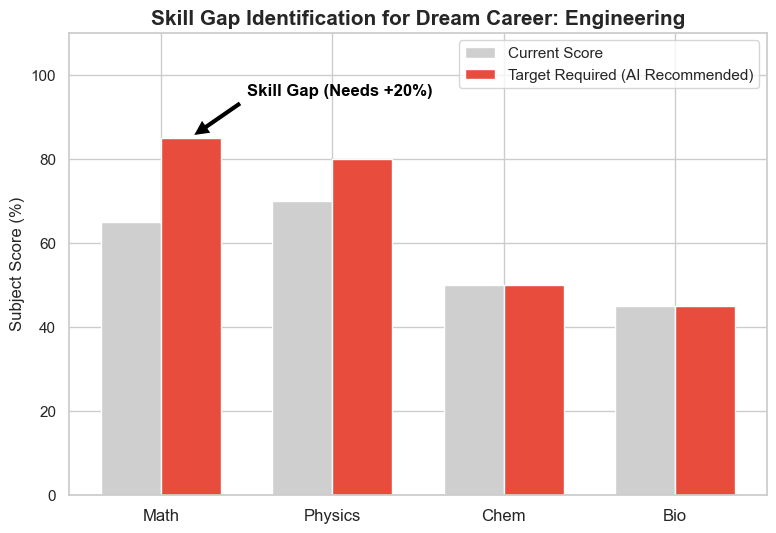

In [4]:
subjects = ['Math', 'Physics', 'Chem', 'Bio']
current_student = [65, 70, 50, 45] # Student is decent at math/physics
target_skills = [85, 80, 50, 45]   # To be an Engineer, they only need to boost Math/Physics (Sparse L1 Penalty)

x = np.arange(len(subjects))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(9, 6))
rects1 = ax.bar(x - width/2, current_student, width, label='Current Score', color='#cfcfcf')
rects2 = ax.bar(x + width/2, target_skills, width, label='Target Required (AI Recommended)', color='#e74c3c')

# Draw the "Gap" arrow
ax.annotate('Skill Gap (Needs +20%)', xy=(0.17, 85), xytext=(0.5, 95), 
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, weight='bold', color='black')

ax.set_ylabel('Subject Score (%)', size=12)
ax.set_title('Skill Gap Identification for Dream Career: Engineering', size=15, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(subjects, size=12)
ax.set_ylim(0, 110)
ax.legend()

plt.show()

### How to use these in your thesis:
- Use the **Radar Chart** when explaining why K-Means is useful (it finds hidden student profiles).
- Use the **Bar Chart** to show the real-world outcome (helping the government or school see where students are headed).
- Use the **Skill Gap Chart** when explaining the advanced MNSS math (showing how the $L_1$ penalty only tells the student to improve specific, targeted subjects).